In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
from utils import load_data, get_classification_split

TARGET = "IC50, mM"
THRESHOLD = None

# Классификация: IC50 > median

## Данные

In [2]:
df = load_data()
X_train, X_test, y_train, y_test = get_classification_split(df, TARGET, threshold=THRESHOLD)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Баланс классов (train):")
display(y_train.value_counts())

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

Train: (800, 192), Test: (201, 192)
Баланс классов (train):


IC50, mM
0    404
1    396
Name: count, dtype: int64

## Модели

In [3]:
models = {
    "LogisticRegression": LogisticRegression(C=1.0, max_iter=5000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=300, max_depth=5, learning_rate=0.1, random_state=42),
    "SVC": SVC(C=1.0, kernel="rbf", probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
}

results = []
fitted_models = {}

for name, model in models.items():
    use_scaled = name in ["LogisticRegression", "SVC", "KNN"]
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc if use_scaled else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba), 4),
    })
    fitted_models[name] = (model, use_scaled)

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,SVC,0.7413,0.7407,0.7692,0.7547,0.7837
1,RandomForest,0.7363,0.7629,0.7115,0.7363,0.7877
0,LogisticRegression,0.7065,0.7143,0.7212,0.7177,0.7541
2,GradientBoosting,0.7164,0.7582,0.6635,0.7077,0.7838
4,KNN,0.6915,0.7283,0.6442,0.6837,0.7468


## ROC-кривые

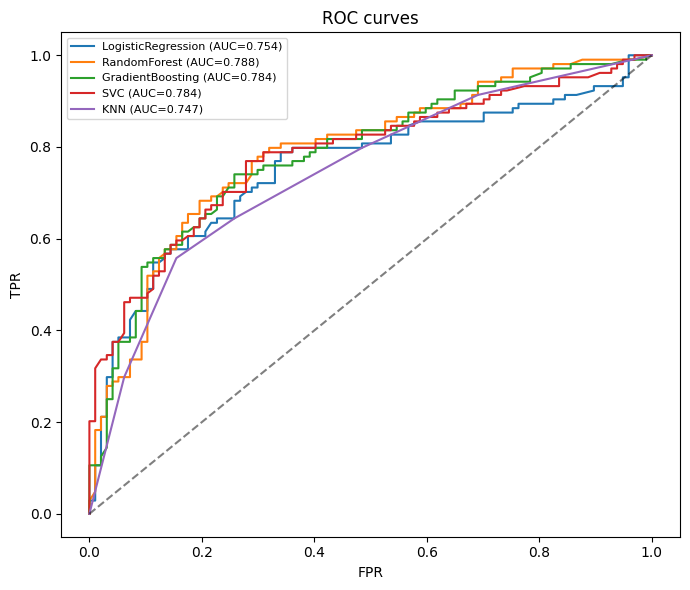

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, (model, use_scaled) in fitted_models.items():
    Xte = X_test_sc if use_scaled else X_test
    y_proba = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("ROC curves")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [6]:
tuned_clf = {}

svc_gs = GridSearchCV(
    SVC(probability=True, random_state=42),
    {"C": [0.5, 1, 5, 10], "kernel": ["rbf", "linear"]},
    cv=5, scoring="f1", n_jobs=-1
)
svc_gs.fit(X_train_sc, y_train)
tuned_clf["SVC"] = svc_gs.best_estimator_
print(f"SVC: {svc_gs.best_params_}")

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {"n_estimators": [200, 400], "max_depth": [8, 12, None], "min_samples_leaf": [1, 3]},
    cv=5, scoring="f1", n_jobs=-1
)
rf_gs.fit(X_train, y_train)
tuned_clf["RandomForest"] = rf_gs.best_estimator_
print(f"RF: {rf_gs.best_params_}")

gbm_gs = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    {"n_estimators": [200, 400], "max_depth": [3, 5], "learning_rate": [0.05, 0.1]},
    cv=5, scoring="f1", n_jobs=-1
)
gbm_gs.fit(X_train, y_train)
tuned_clf["GradientBoosting"] = gbm_gs.best_estimator_
print(f"GBM: {gbm_gs.best_params_}")

for name, model in tuned_clf.items():
    use_scaled = name == "SVC"
    Xte = X_test_sc if use_scaled else X_test
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]
    print(f"{name}: F1={f1_score(y_test, y_pred):.4f}, ROC-AUC={roc_auc_score(y_test, y_proba):.4f}")
    fitted_models[name] = (model, use_scaled)


SVC: {'C': 5, 'kernel': 'rbf'}
RF: {'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 400}
GBM: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
SVC: F1=0.7463, ROC-AUC=0.7735
RandomForest: F1=0.7300, ROC-AUC=0.7948
GradientBoosting: F1=0.7129, ROC-AUC=0.8000


## Feature importance

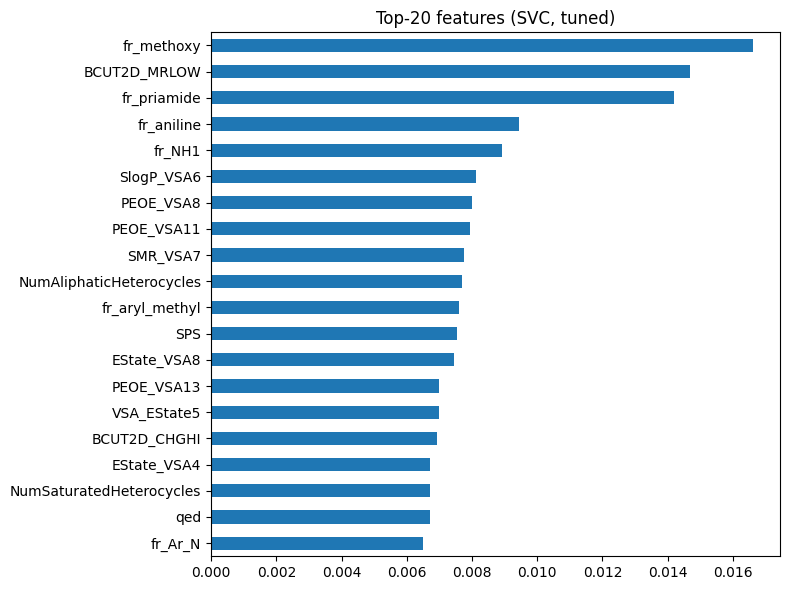

In [15]:
def predict_f1(name):
    model = tuned_clf[name]
    Xte = X_test_sc if name == "SVC" else X_test
    return f1_score(y_test, model.predict(Xte))

best_name = max(tuned_clf, key=predict_f1)
best_model = tuned_clf[best_name]
Xte = X_test_sc if best_name == "SVC" else X_test

if hasattr(best_model, "feature_importances_"):
    feat_imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)
else:
    perm = permutation_importance(best_model, Xte, y_test, n_repeats=10, random_state=42, scoring="f1", n_jobs=-1)
    feat_imp = pd.Series(perm.importances_mean, index=X_train.columns).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_title(f"Top-20 features ({best_name}, tuned)")
plt.tight_layout()
plt.show()


## Confusion matrix (лучшая модель)

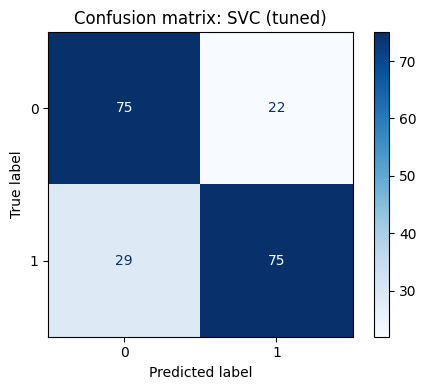

In [17]:
best_model = tuned_clf["SVC"]
y_pred = best_model.predict(X_test_sc)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
ax.set_title("Confusion matrix: SVC (tuned)")
plt.tight_layout()
plt.show()


## Выводы

SVC лучший по F1 (0.75), но RF и GBM обгоняют по AUC (0.79-0.80). Тюнинг дал минимальный эффект. По permutation importance для SVC на первом месте fr_methoxy - интересно, что для регрессии этот признак в топ не попадал.